Data Normalization Check: Range [-4.91, 2.88]

Sample of Correlation Features (R-squared, Variance):
[[0.95885007 0.87458462]
 [0.8576245  0.91028752]
 [0.93043327 0.88133299]
 [0.96539215 0.87557081]
 [0.92020437 0.81626139]]


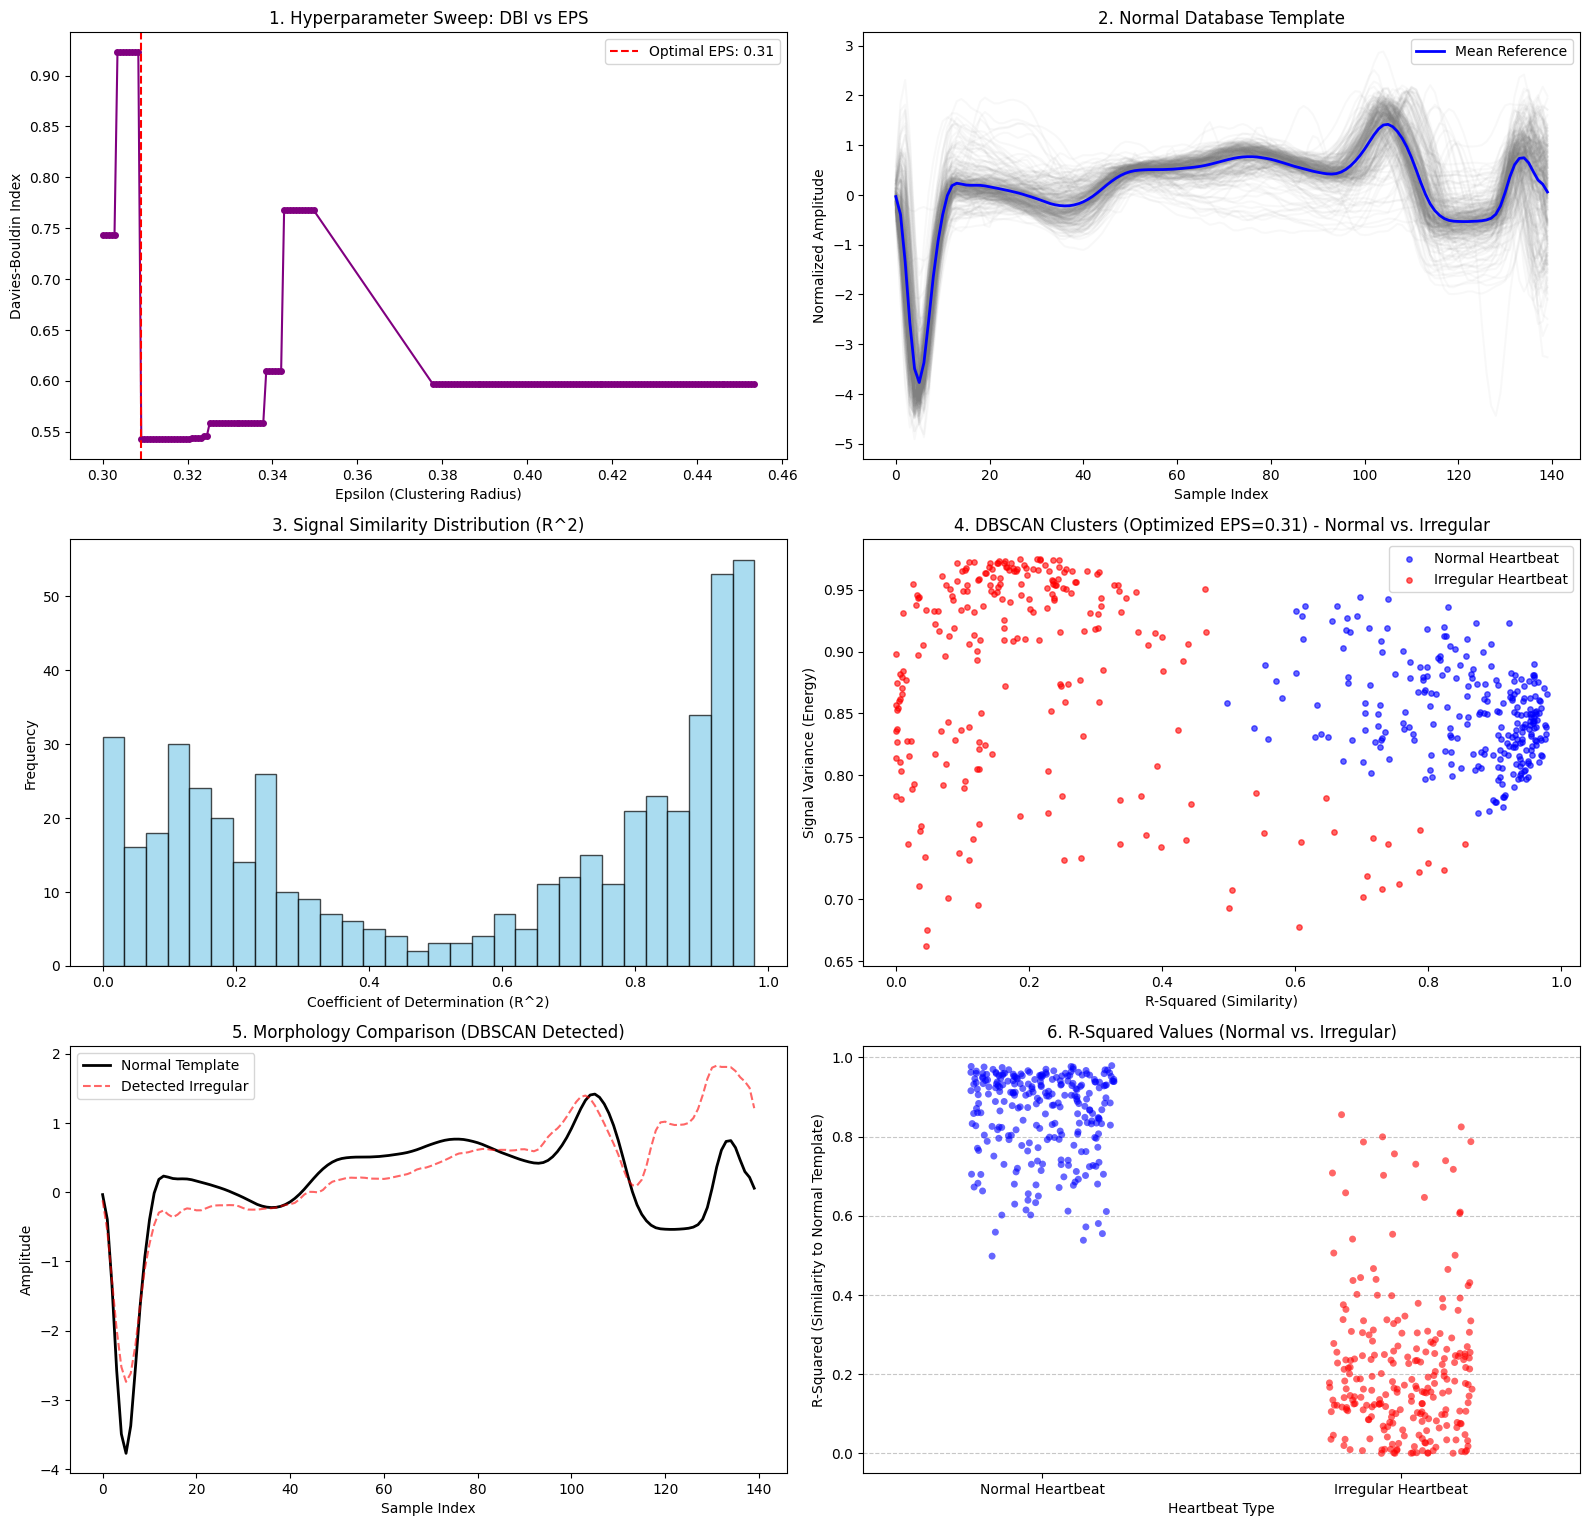

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
from scipy.io import arff
from scipy.stats import pearsonr
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. DATA LOADING AND PREPARATION
train_data, _ = arff.loadarff("/content/drive/MyDrive/Colab Notebooks/ECG5000/ECG5000_TRAIN.arff")
train_df = pd.DataFrame(train_data)

# Convert byte strings to strings and numeric
# The last column is usually the target/label
for col in train_df.columns:
  if train_df[col].dtype == object:
    train_df[col] = train_df[col].str.decode('utf-8')

# Feature & Target Extraction (140 samples)
X_raw = train_df.iloc[:, :-1].values.astype(float) # Signal amplitude data
y = train_df.iloc[:, -1].values # Ground truth Labels

# 2. SIGNAL CONDITIONING
def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=250, order=2):
  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq
  b, a = signal.butter(order, [low, high], btype='band')
  return signal.lfilter(b, a, data)

def calculate_snr(signal_orig, signal_filt):
  noise = signal_orig - signal_filt
  return 10 * np.log10(np.sum(signal_filt**2) / np.sum(noise**2))

# Apply filtering to all signals
X_filt = np.array([bandpass_filter(row) for row in X_raw])

# 3. NORMAL DATABASE ANALYSIS & REFERENCE MEAN

# Identify normal heartbeats (Label '1' in ECG5000)
normal_mask = (y == '1')
X_normal = X_filt[normal_mask]

# Get the Mean of the Normal Heartbeats (The System Template)
mean_normal = np.mean(X_normal, axis=0)

# Check Normalization: Check if mean is near 0 and scale is consistent
data_min, data_max = X_normal.min(), X_normal.max()
print(f"Data Normalization Check: Range [{data_min:.2f}, {data_max:.2f}]")

# 4. PEARSON CORRELATION AND R-SQUARED
def get_correlation_features(X_data, reference_signal):
  features = []
  for sig in X_data:
    r, _ = pearsonr(sig, reference_signal)
    r_sq = r**2 # R-squared as a measure of similarity
    features.append([r_sq, np.var(sig)])
  return np.array(features)

X_corr_features = get_correlation_features(X_filt, mean_normal)

# Display a sample of the correlation features
print("\nSample of Correlation Features (R-squared, Variance):")
print(X_corr_features[:5])

# 5. DBSCAN CLUSTERING

def ecg_dbscan(X_features, eps_range=(0.3, 1), num_eps=1000, min_samples=3):
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X_features)

  eps_values = np.linspace(eps_range[0], eps_range[1], num_eps)
  db_scores = []
  valid_eps = []

  for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    # DBI requires at least 2 clusters (excluding noise -1)
    unique_clusters = np.unique(labels[labels != -1])
    if len(unique_clusters) >= 2:
      mask = labels != -1
      score = davies_bouldin_score(X_scaled[mask], labels[mask])
      db_scores.append(score)
      valid_eps.append(eps)

  # --- SAFETY CHECK ---
  if not db_scores:
    print("Optimization failed to find multiple clusters. Using fallback parameters.")
    best_eps = 0.5
    final_db = DBSCAN(eps=best_eps, min_samples=min_samples).fit(X_scaled)
    return final_db.labels_, [0], [best_eps], best_eps

  best_eps = valid_eps[np.argmin(db_scores)]
  final_db = DBSCAN(eps=best_eps, min_samples=min_samples).fit(X_scaled)
  return final_db.labels_, db_scores, valid_eps, best_eps

final_labels, dbi_scores, valid_eps, best_eps = ecg_dbscan(X_corr_features)

def plot_optimization_report(X_raw, X_filt, X_normal, mean_normal, final_labels, X_features, valid_eps, dbi_scores, best_eps):
    fig = plt.figure(figsize=(16, 20)) # Adjusted figure size for 6 plots

    # Plot 1: EPS Sweep Result (Quantitative Optimization)
    plt.subplot(4, 2, 1) # Changed to 4 rows
    plt.plot(valid_eps, dbi_scores, marker='o', color='purple', markersize=4)
    plt.axvline(best_eps, color='red', linestyle='--', label=f'Optimal EPS: {best_eps:.2f}')
    plt.title("1. Hyperparameter Sweep: DBI vs EPS")
    plt.xlabel("Epsilon (Clustering Radius)")
    plt.ylabel("Davies-Bouldin Index")
    plt.legend()

    # Plot 2: Normal Database Validation
    plt.subplot(4, 2, 2) # Changed to 4 rows
    plt.plot(X_normal.T, color='gray', alpha=0.05)
    plt.plot(mean_normal, color='blue', linewidth=2, label='Mean Reference')
    plt.title("2. Normal Database Template")
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Amplitude")
    plt.legend()

    # Plot 3: R-Squared Distribution (System Linearity)
    plt.subplot(4, 2, 3) # Changed to 4 rows
    plt.hist(X_features[:, 0], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("3. Signal Similarity Distribution (R^2)")
    plt.xlabel("Coefficient of Determination (R^2)")
    plt.ylabel("Frequency")

    # Plot 4: Final Clusters (Unsupervised Results)
    plt.subplot(4, 2, 4) # Changed to 4 rows

    # Determine the normal cluster for DBSCAN
    # Exclude noise points (label -1) when calculating cluster means
    unique_cluster_labels = np.unique(final_labels[final_labels != -1])

    if len(unique_cluster_labels) > 0:
        cluster_means = [np.mean(X_features[final_labels == i, 0]) for i in unique_cluster_labels]
        normal_cluster_label_dbscan = unique_cluster_labels[np.argmax(cluster_means)]
    else:
        # Fallback if only noise or a single cluster exists after filtering -1
        normal_cluster_label_dbscan = 0 # Default to 0 if no clear normal cluster is found

    # Create masks for normal and irregular heartbeats (including noise as irregular)
    normal_mask_dbscan_plot = (final_labels == normal_cluster_label_dbscan)
    irregular_mask_dbscan_plot = (final_labels != normal_cluster_label_dbscan)

    # Plot normal heartbeats
    plt.scatter(X_features[normal_mask_dbscan_plot, 0], X_features[normal_mask_dbscan_plot, 1],
                c='blue', s=15, alpha=0.6, label='Normal Heartbeat')
    # Plot irregular heartbeats (including noise)
    plt.scatter(X_features[irregular_mask_dbscan_plot, 0], X_features[irregular_mask_dbscan_plot, 1],
                c='red', s=15, alpha=0.6, label='Irregular Heartbeat')

    plt.title(f"4. DBSCAN Clusters (Optimized EPS={best_eps:.2f}) - Normal vs. Irregular")
    plt.xlabel("R-Squared (Similarity)")
    plt.ylabel("Signal Variance (Energy)")
    plt.legend()

    # Plot 5: Morphology Comparison (DBSCAN Detected)
    plt.subplot(4, 2, 5) # Changed to 4 rows
    irreg_idx = np.where(final_labels != normal_cluster_label_dbscan)[0]
    plt.plot(mean_normal, label='Normal Template', color='black', linewidth=2)
    if len(irreg_idx) > 0:
        plt.plot(X_filt[irreg_idx[0]], label='Detected Irregular', color='red', alpha=0.6, linestyle='--')
    plt.title("5. Morphology Comparison (DBSCAN Detected)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()

    # Plot 6: R-Squared Values for Normal vs. Irregular Heartbeats (Scatterplot)
    plt.subplot(4, 2, 6) # Added new subplot as 6th

    # Extract R-squared values for normal and irregular heartbeats (using the same masks)
    r_squared_normal = X_corr_features[normal_mask_dbscan_plot, 0]
    r_squared_irregular = X_corr_features[irregular_mask_dbscan_plot, 0]

    # Create a DataFrame for plotting
    data_for_plot = pd.DataFrame({
        'R-Squared': np.concatenate([r_squared_normal, r_squared_irregular]),
        'Heartbeat Type': ['Normal Heartbeat'] * len(r_squared_normal) + ['Irregular Heartbeat'] * len(r_squared_irregular)
    })

    # Use stripplot to show individual data points
    sns.stripplot(x='Heartbeat Type', y='R-Squared', data=data_for_plot,
                  hue='Heartbeat Type', jitter=0.2, palette={'Normal Heartbeat': 'blue', 'Irregular Heartbeat': 'red'},
                  alpha=0.6, s=5, legend=False)

    plt.title('6. R-Squared Values (Normal vs. Irregular)')
    plt.xlabel('Heartbeat Type')
    plt.ylabel('R-Squared (Similarity to Normal Template)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_optimization_report(X_raw, X_filt, X_normal, mean_normal, final_labels, X_corr_features, valid_eps, dbi_scores, best_eps)

--- DBSCAN Evaluation ---
Ground Truth (Normal=1, Irregular=0) count: 292 Normal, 208 Irregular
DBSCAN Predicted (Normal=1, Irregular=0) count: 259 Normal, 241 Irregular
Accuracy: 0.9300
Precision (Normal): 0.9961
Recall (Normal): 0.8836
F1-Score (Normal): 0.9365

Confusion Matrix (True vs Predicted):
  [[TN FP]
   [FN TP]] for (Irregular vs Normal)

[[207   1]
 [ 34 258]]


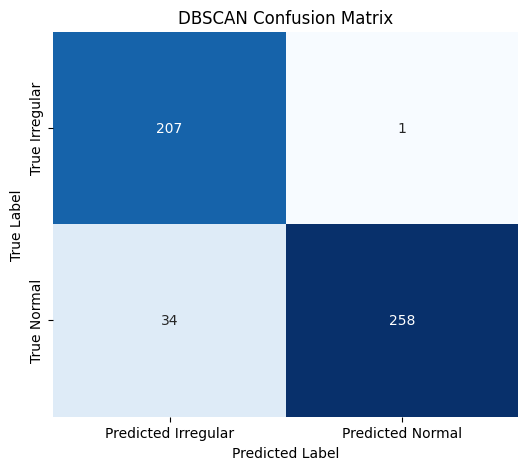

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Prepare ground truth labels
y_true = (y == '1').astype(int) # 1 for Normal, 0 for Irregular (or other anomalies)

# Prepare predicted labels from DBSCAN
# We already determined 'normal_cluster_label_dbscan' in the plotting function.
# Re-calculating to ensure consistency and availability
unique_cluster_labels_eval = np.unique(final_labels[final_labels != -1])
if len(unique_cluster_labels_eval) > 0:
    cluster_means_eval = [np.mean(X_corr_features[final_labels == i, 0]) for i in unique_cluster_labels_eval]
    normal_cluster_label_dbscan_eval = unique_cluster_labels_eval[np.argmax(cluster_means_eval)]
else:
    normal_cluster_label_dbscan_eval = None

# Map DBSCAN labels to binary (1 for Normal, 0 for Irregular/Noise)
y_pred_dbscan = np.zeros(len(final_labels)) # Initialize all as irregular (0)
if normal_cluster_label_dbscan_eval is not None:
    y_pred_dbscan[final_labels == normal_cluster_label_dbscan_eval] = 1 # Mark normal cluster as 1

print("--- DBSCAN Evaluation ---")
print(f"Ground Truth (Normal=1, Irregular=0) count: {np.sum(y_true==1)} Normal, {np.sum(y_true==0)} Irregular")
print(f"DBSCAN Predicted (Normal=1, Irregular=0) count: {np.sum(y_pred_dbscan==1)} Normal, {np.sum(y_pred_dbscan==0)} Irregular")

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred_dbscan)
precision = precision_score(y_true, y_pred_dbscan, pos_label=1) # Precision for Normal class
recall = recall_score(y_true, y_pred_dbscan, pos_label=1)     # Recall for Normal class
f1 = f1_score(y_true, y_pred_dbscan, pos_label=1)           # F1-score for Normal class

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Normal): {precision:.4f}")
print(f"Recall (Normal): {recall:.4f}")
print(f"F1-Score (Normal): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_dbscan)
print("\nConfusion Matrix (True vs Predicted):\n  [[TN FP]\n   [FN TP]] for (Irregular vs Normal)\n")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Irregular', 'Predicted Normal'],
            yticklabels=['True Irregular', 'True Normal'])
plt.title('DBSCAN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 6. Model Testing and Evaluation on a New Dataset

In [ ]:
# 6.1. Load Test Data
test_data, _ = arff.loadarff("/content/drive/MyDrive/Colab Notebooks/ECG5000/ECG5000_TEST.arff")
test_df = pd.DataFrame(test_data)

# Convert byte strings to strings and numeric
for col in test_df.columns:
  if test_df[col].dtype == object:
    test_df[col] = test_df[col].str.decode('utf-8')

# Feature & Target Extraction
X_raw_test = test_df.iloc[:, :-1].values.astype(float) # Signal amplitude data
y_test = test_df.iloc[:, -1].values # Ground truth Labels

print(f"Test Data Shape: {X_raw_test.shape}")
print(f"Test Labels Shape: {y_test.shape}")

Test Data Shape: (4500, 140)
Test Labels Shape: (4500,)


In [ ]:
# 6.2. Signal Conditioning for Test Data
X_filt_test = np.array([bandpass_filter(row) for row in X_raw_test])


In [ ]:
# 6.3. Feature Extraction for Test Data (using reference from training)
X_corr_features_test = get_correlation_features(X_filt_test, mean_normal)

print("\nSample of Test Correlation Features (R-squared, Variance):")
print(X_corr_features_test[:5])


Sample of Test Correlation Features (R-squared, Variance):
[[0.61431935 0.84392138]
 [0.90985289 0.81861384]
 [0.70053516 0.75842195]
 [0.91839059 0.85995021]
 [0.8689553  0.75748263]]


In [ ]:
# 6.4. Apply DBSCAN with Optimized EPS on Test Data
scaler_test = StandardScaler()
X_scaled_test = scaler_test.fit_transform(X_corr_features_test)

# Use the 'best_eps' found during training optimization
db_test = DBSCAN(eps=best_eps, min_samples=3).fit(X_scaled_test)
final_labels_test = db_test.labels_

print(f"DBSCAN applied to test data with optimal EPS: {best_eps:.2f}")
print(f"Unique labels found in test data: {np.unique(final_labels_test)}")

DBSCAN applied to test data with optimal EPS: 0.31
Unique labels found in test data: [-1  0]



--- DBSCAN Evaluation on Test Data ---
Ground Truth (Normal=1, Irregular=0) count: 2627 Normal, 1873 Irregular
DBSCAN Predicted (Normal=1, Irregular=0) count: 4492 Normal, 8 Irregular
Accuracy (Test): 0.5847
Precision (Normal, Test): 0.5844
Recall (Normal, Test): 0.9992
F1-Score (Normal, Test): 0.7375

Confusion Matrix (Test Data - True vs Predicted):
  [[TN FP]
   [FN TP]] for (Irregular vs Normal)

[[   6 1867]
 [   2 2625]]


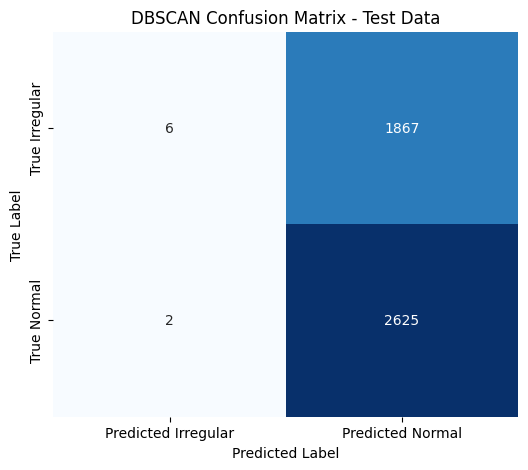

In [ ]:
# 6.5. Evaluation on Test Data

y_true_test = (y_test == '1').astype(int) # 1 for Normal, 0 for Irregular (or other anomalies)

# Determine the normal cluster label for the test set
unique_cluster_labels_test_eval = np.unique(final_labels_test[final_labels_test != -1])
if len(unique_cluster_labels_test_eval) > 0:
    # Assuming the cluster with the highest mean R-squared is the 'normal' one
    cluster_means_test_eval = [np.mean(X_corr_features_test[final_labels_test == i, 0]) for i in unique_cluster_labels_test_eval]
    normal_cluster_label_dbscan_test = unique_cluster_labels_test_eval[np.argmax(cluster_means_test_eval)]
else:
    normal_cluster_label_dbscan_test = None # No normal cluster found

# Map DBSCAN labels to binary (1 for Normal, 0 for Irregular/Noise)
y_pred_dbscan_test = np.zeros(len(final_labels_test)) # Initialize all as irregular (0)
if normal_cluster_label_dbscan_test is not None:
    y_pred_dbscan_test[final_labels_test == normal_cluster_label_dbscan_test] = 1 # Mark normal cluster as 1

print("\n--- DBSCAN Evaluation on Test Data ---")
print(f"Ground Truth (Normal=1, Irregular=0) count: {np.sum(y_true_test==1)} Normal, {np.sum(y_true_test==0)} Irregular")
print(f"DBSCAN Predicted (Normal=1, Irregular=0) count: {np.sum(y_pred_dbscan_test==1)} Normal, {np.sum(y_pred_dbscan_test==0)} Irregular")

# Calculate metrics
accuracy_test = accuracy_score(y_true_test, y_pred_dbscan_test)
precision_test = precision_score(y_true_test, y_pred_dbscan_test, pos_label=1) # Precision for Normal class
recall_test = recall_score(y_true_test, y_pred_dbscan_test, pos_label=1)     # Recall for Normal class
f1_test = f1_score(y_true_test, y_pred_dbscan_test, pos_label=1)           # F1-score for Normal class

print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"Precision (Normal, Test): {precision_test:.4f}")
print(f"Recall (Normal, Test): {recall_test:.4f}")
print(f"F1-Score (Normal, Test): {f1_test:.4f}")

# Confusion Matrix
cm_test = confusion_matrix(y_true_test, y_pred_dbscan_test)
print("\nConfusion Matrix (Test Data - True vs Predicted):\n  [[TN FP]\n   [FN TP]] for (Irregular vs Normal)\n")
print(cm_test)

# Visualize Confusion Matrix for Test Data
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Irregular', 'Predicted Normal'],
            yticklabels=['True Irregular', 'True Normal'])
plt.title('DBSCAN Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()